<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None
             Type     Alcohol       Malic         Ash  Alcalinity   Magnesium  \
count  178.000000  17

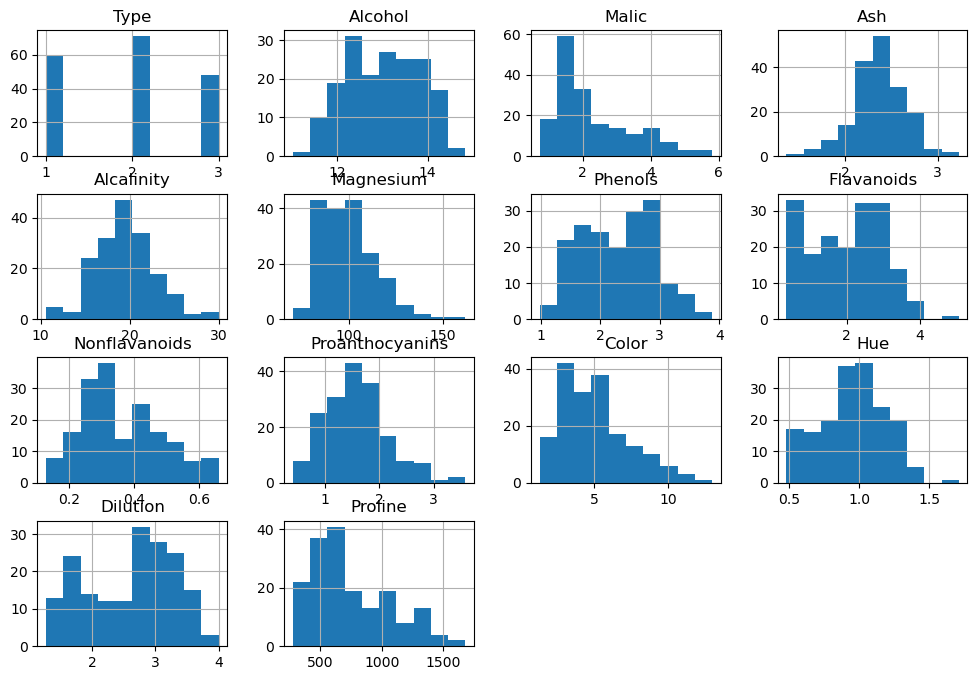

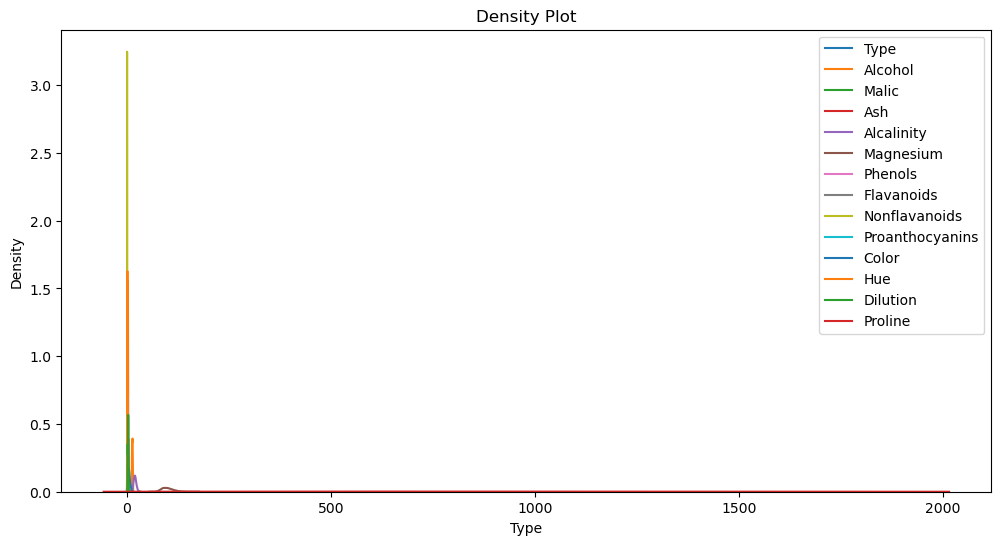

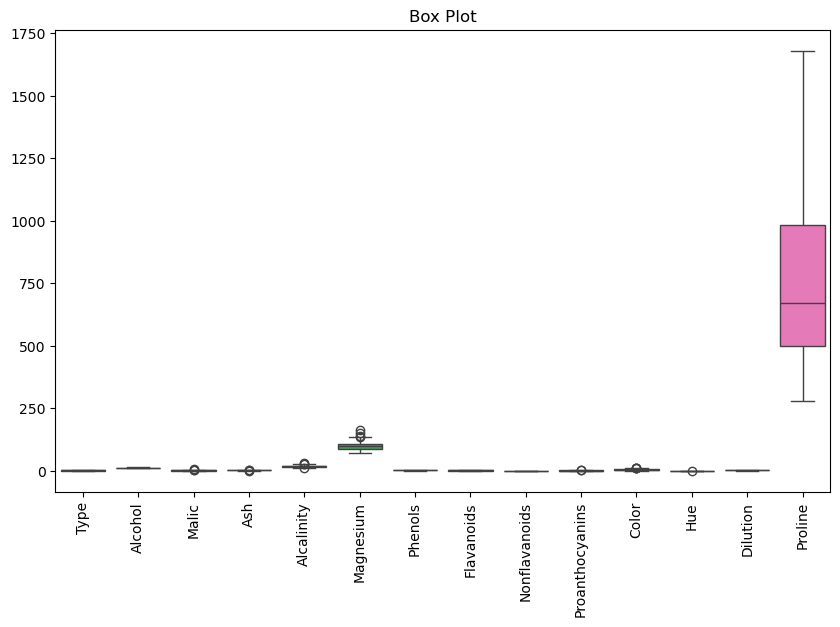

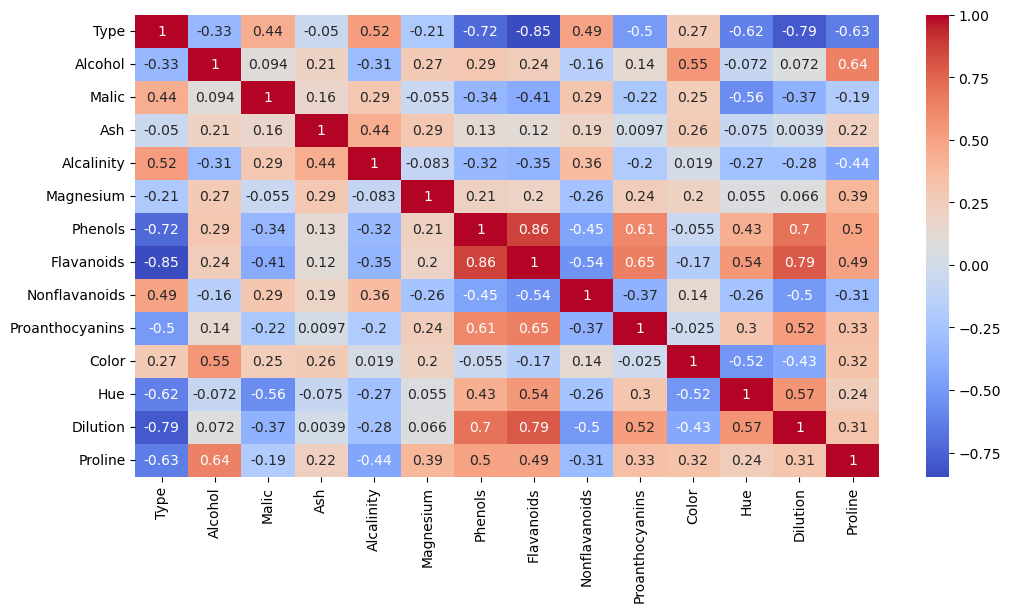

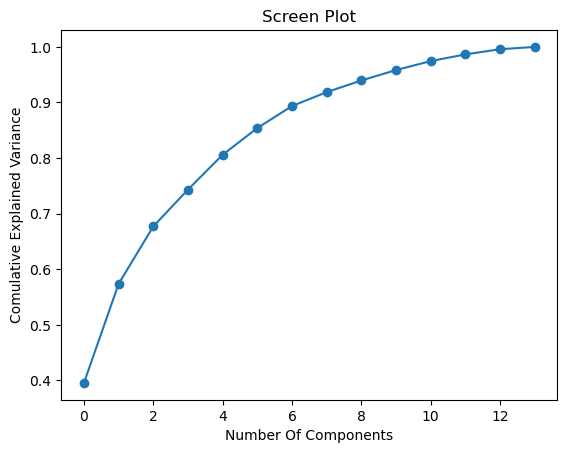

        PC1       PC2
0 -3.522934  1.453098
1 -2.528858 -0.330019
2 -2.785029  1.036936
3 -3.922588  2.768210
4 -1.407511  0.867773


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

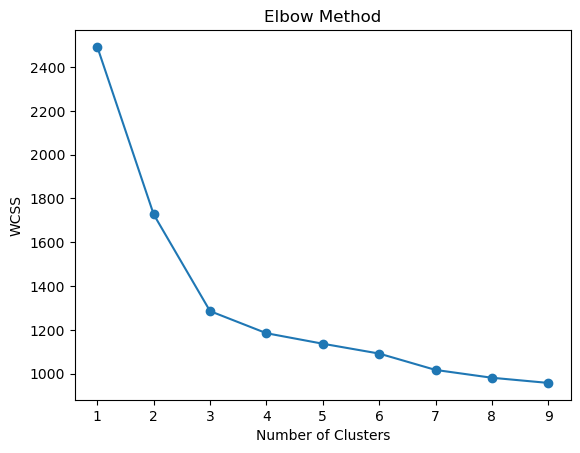

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


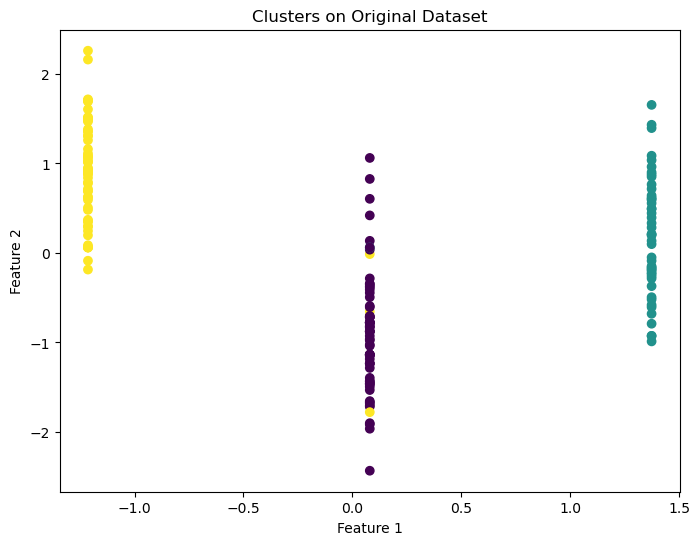

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Original Data Silhouette Score: 0.30648398324833453
Original Data DB Index: 1.315707552261773


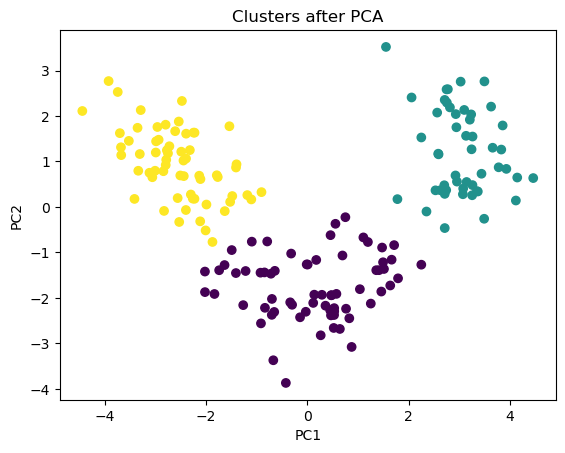

PCA Silhouette Score: 0.6024415520362845
PCA DB Index: 0.5397078562575711

--- COMPARISON ---
Original Silhouette : 0.30648398324833453
PCA Silhouette      : 0.6024415520362845

Original DB Index : 1.315707552261773
PCA DB Index      : 0.5397078562575711


In [1]:
import pandas as pd

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\wine.csv"
)

# ==========================================
# DATA OVERVIEW
# ==========================================

print(df.info())

print(df.describe())

print(df.head())

print(df.isnull().sum())

# ==========================================
# VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
df.hist(figsize=(12,8))

plt.show()

# Density Plot
plt.figure(figsize=(12,6))

for col in df.columns:
    sns.kdeplot(df[col], label=col)

plt.title("Density Plot")

plt.legend()

plt.show()

# Box Plot
plt.figure(figsize=(10,6))

sns.boxplot(df)

plt.title("Box Plot")

plt.xticks(rotation=90)

plt.show()

# Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

# ==========================================
# FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

# ==========================================
# PCA
# ==========================================

from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

import numpy as np

# Scree Plot
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number Of Components")

plt.ylabel("Comulative Explained Variance")

plt.title("Screen Plot")

plt.show()

# PCA with 2 Components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)

print(pca_df.head())

# ==========================================
# K-MEANS CLUSTERING
# ==========================================

from sklearn.cluster import KMeans

wcss = []

for i in range(1,10):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

# Elbow Plot
plt.plot(range(1,10), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# ==========================================
# ORIGINAL DATA CLUSTERING
# ==========================================

kmeans_org = KMeans(
    n_clusters=3,
    random_state=42
)

labels_org = kmeans_org.fit_predict(X_scaled)

# Scatter Plot for Original Dataset Clustering
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels_org,
    cmap='viridis'
)

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title("Clusters on Original Dataset")

plt.show()

# ==========================================
# CLUSTER EVALUATION
# ==========================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

print(
    "Original Data Silhouette Score:",
    silhouette_score(X_scaled, labels_org)
)

print(
    "Original Data DB Index:",
    davies_bouldin_score(X_scaled, labels_org)
)

# ==========================================
# PCA CLUSTERING
# ==========================================

kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

labels_pca = kmeans_pca.fit_predict(X_pca)

# PCA Scatter Plot
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_pca,
    cmap='viridis'
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Clusters after PCA")

plt.show()

# ==========================================
# PCA EVALUATION
# ==========================================

print(
    "PCA Silhouette Score:",
    silhouette_score(X_pca, labels_pca)
)

print(
    "PCA DB Index:",
    davies_bouldin_score(X_pca, labels_pca)
)

# ==========================================
# COMPARISON
# ==========================================

print("\n--- COMPARISON ---")

print(
    "Original Silhouette :",
    silhouette_score(X_scaled, labels_org)
)

print(
    "PCA Silhouette      :",
    silhouette_score(X_pca, labels_pca)
)

print(
    "\nOriginal DB Index :",
    davies_bouldin_score(X_scaled, labels_org)
)

print(
    "PCA DB Index      :",
    davies_bouldin_score(X_pca, labels_pca)
)

PCA reduced dimensionality while preserving most variance
KMeans performed faster on PCA data
PCA clusters are easier to visualize
Slight accuracy trade-off may occur
PCA improves clustering efficiency and interpretability but may lose minor information. For large datasets, PCA + clustering is recommended.
